In [25]:



import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import roc_auc_score, roc_curve

import matplotlib.pyplot as plt


from sklearn.impute import SimpleImputer


In [26]:
df = pd.read_excel("Churn (1) (1) (1).xlsx")

In [27]:
df = df.drop(columns = ["Unnamed: 0"])

In [28]:
df["churn"] = df["churn"].map({"yes":1, "no":0})

In [30]:
df.isnull().sum()

,0
state,0
area.code,0
account.length,0
voice.plan,0
voice.messages,0
intl.plan,0
intl.mins,0
intl.calls,0
intl.charge,0
day.mins,0


In [31]:
df["area.code"] = df["area.code"].str.split("_").str[-1].astype(int)


In [32]:
cat_cols = ["state", "voice.plan", "intl.plan"]
num_cols = [col for col in X.columns if col not in cat_cols]


In [33]:
# Redefine preprocessor to include SimpleImputer for numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')), # Impute missing numerical values
            ('scaler', StandardScaler())
        ]), num_cols)
    ]
)

In [35]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [36]:
df.tail()

,state,area.code,account.length,voice.plan,voice.messages,intl.plan,intl.mins,intl.calls,intl.charge,day.mins,day.calls,day.charge,eve.mins,eve.calls,eve.charge,night.mins,night.calls,night.charge,customer.calls,churn
4995,HI,408,50,yes,40,no,9.9,5,2.67,235.7,127,40.07,223,126,18.96,297.5,116,13.39,2,0
4996,WV,415,152,no,0,no,14.7,2,3.97,184.2,90,31.31,256.8,73,21.83,213.6,113,9.61,3,1
4997,DC,415,61,no,0,no,13.6,4,3.67,140.6,89,23.9,172.8,128,14.69,212.4,97,9.56,1,0
4998,DC,510,109,no,0,no,8.5,6,2.30,188.8,67,32.1,171.7,92,14.59,224.4,89,10.10,0,0
4999,VT,415,86,yes,34,no,9.3,16,2.51,129.4,102,22,267.1,104,22.70,154.8,100,6.97,0,0


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:

log_pipeline = Pipeline([
    ("Preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_pipeline.fit(X_train, y_train)
log_probs = log_pipeline.predict_proba(X_test)[:,1]
log_auc = roc_auc_score(y_test, log_probs)
print("Logistic Regression AUC:", log_auc)


Logistic Regression AUC: 0.8316663742176991


In [39]:
rf_pipeline = Pipeline([
    ("Preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10]
}

rf_grid = GridSearchCV(rf_pipeline, rf_params, cv=5, scoring="roc_auc", n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_probs = rf_grid.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_probs)
print("Random Forest AUC:", rf_auc)

Random Forest AUC: 0.9192255951336492


In [40]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
xgb_probs = xgb_best.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_probs)

print("XGBoost AUC:", xgb_auc)


XGBoost AUC: 0.9250453295899865


In [41]:
models = {"Logistic": log_probs,
          "Random Forest": rf_probs,
          "XGBoost": xgb_probs}

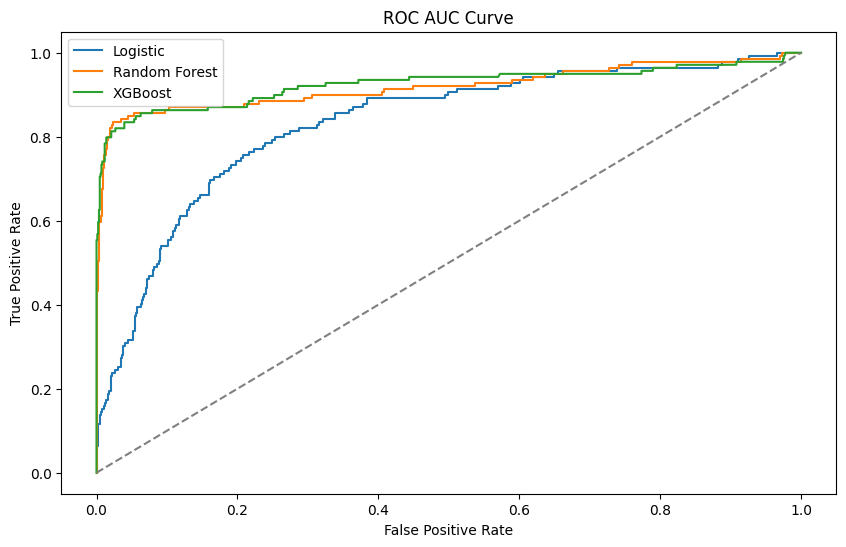

In [42]:
plt.figure(figsize=(10, 6))

for name, probs in models.items():
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)


plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve')
plt.legend()
plt.show()

In [43]:
import pickle

with open("churn_pipeline.pkl", "wb") as f:
    pickle.dump(xgb_best, f)

In [44]:
from google.colab import files
files.download("churn_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
import sklearn
print(sklearn.__version__)


1.6.1
